In [1]:
import ast
import sys
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
# test file: project_root/src/tests/this_file.py
project_root = Path.cwd().parents[1]

sys.path.insert(0, str(project_root.resolve()))

In [2]:
data_dir = project_root / "src" / "data"/"processed"
df = pd.read_csv(data_dir / "features.csv")
def future_volatility_5d(group):
    returns = group["log_return"]

    future_vol = pd.Series(
        [
            returns.iloc[i+1:i+6].std()
            if i + 5 < len(returns)
            else np.nan
            for i in range(len(returns))
        ],
        index=group.index
    )

    return future_vol


df["future_volatility_5d"] = (
    df.groupby("ticker", group_keys=False)
      .apply(future_volatility_5d)
)

C:\Users\ferna\AppData\Local\Temp\ipykernel_25248\1854300278.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(future_volatility_5d)


In [3]:
features = [
    "log_return",
    "return_5d",
    "return_10d",
    "return_20d",
    "volatility_5d",
    "volatility_10d",
    "volatility_20d",
    "volatility_60d",
]
df_model = df.dropna(
    subset=features + ["future_volatility_5d"]
).copy()

In [4]:
split_date = "2025-01-01"

train = df_model[df_model["date"] < split_date].copy()
test = df_model[df_model["date"] >= split_date].copy()

X_train = train[features]
y_train = train["future_volatility_5d"]

X_test = test[features]
y_test = test["future_volatility_5d"]


baseline_predictions = test["volatility_5d"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 0.010625863989665692
Baseline RMSE: 0.016203136312115198


In [5]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("ML Model")
print("MAE:", mae)
print("RMSE:", rmse)

print("\nBaseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

ML Model
MAE: 0.00826128727010005
RMSE: 0.012889485054386866

Baseline
MAE: 0.010625863989665692
RMSE: 0.016203136312115198


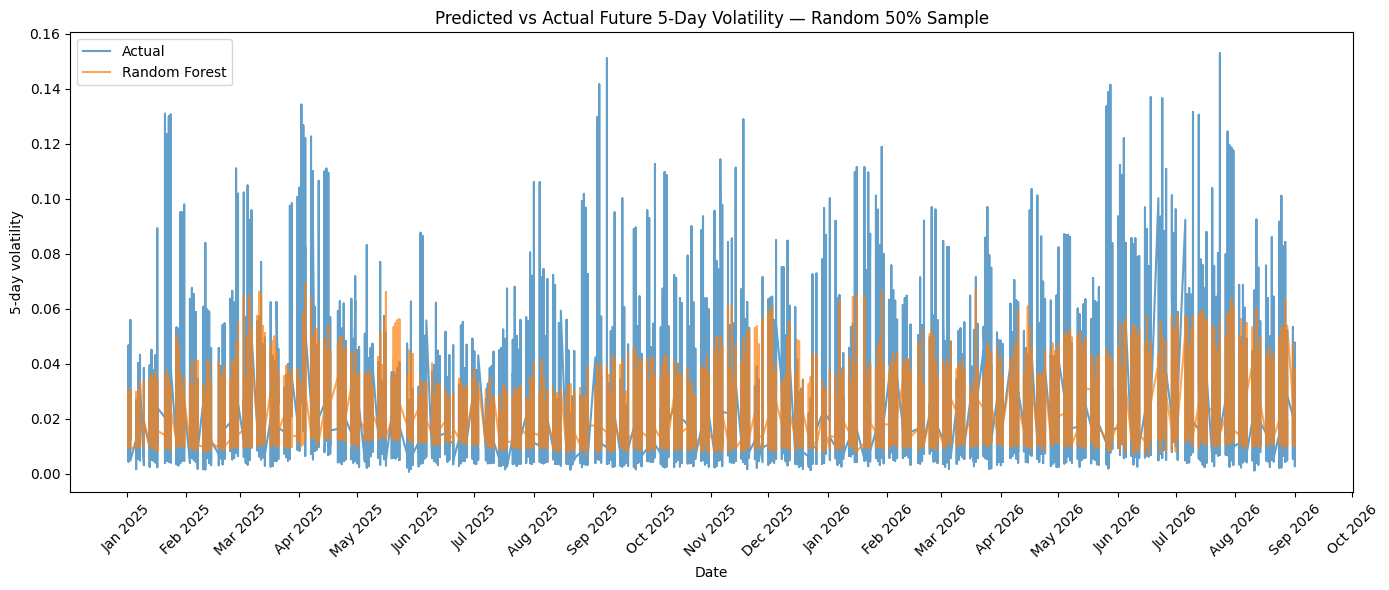

In [8]:
import matplotlib.dates as mdates

plot_data = pd.DataFrame({
    "date": pd.to_datetime(test["date"]),
    "actual": y_test.to_numpy(),
    "prediction": predictions,
})

plot_data = (
    plot_data
    .sample(frac=0.5, random_state=42)
    .sort_values("date")
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["actual"],
    label="Actual",
    alpha=0.7,
)

plt.plot(
    plot_data["date"],
    plot_data["prediction"],
    label="Random Forest",
    alpha=0.7,
)

plt.xlabel("Date")
plt.ylabel("5-day volatility")
plt.title("Predicted vs Actual Future 5-Day Volatility — Random 50% Sample")
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
baseline_10d = test["volatility_10d"]
baseline_20d = test["volatility_20d"]
baseline_60d = test["volatility_60d"]

for name, pred in [
    ("5d volatility", baseline_predictions),
    ("10d volatility", baseline_10d),
    ("20d volatility", baseline_20d),
    ("60d volatility", baseline_60d)
]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(name)
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")

5d volatility
  MAE:  0.010626
  RMSE: 0.016203
10d volatility
  MAE:  0.010002
  RMSE: 0.015038
20d volatility
  MAE:  0.009481
  RMSE: 0.014037
60d volatility
  MAE:  0.009277
  RMSE: 0.013503


In [9]:
correlation = np.corrcoef(
    y_test,
    predictions
)[0, 1]

print(f"Correlation: {correlation:.4f}")

Correlation: 0.5458


In [10]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print(f"R²: {r2:.4f}")

R²: 0.2901


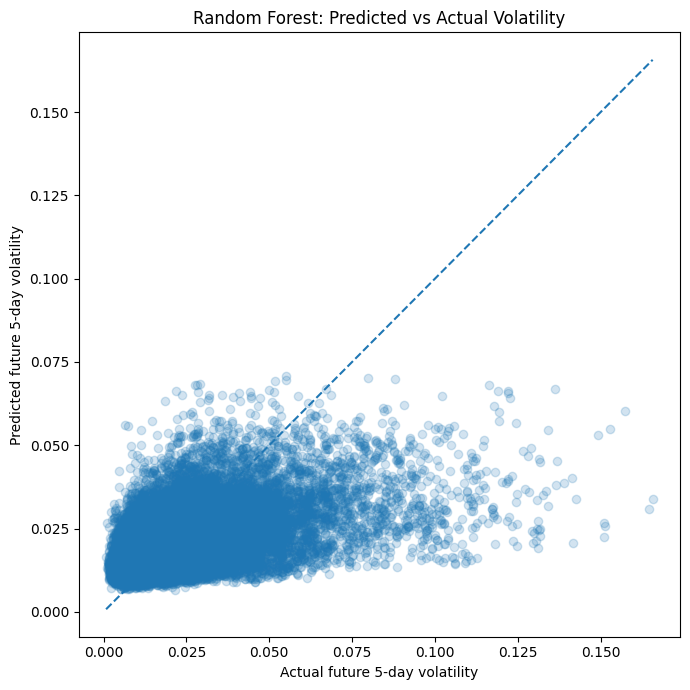

In [11]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.2
)

# Perfect prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual future 5-day volatility")
plt.ylabel("Predicted future 5-day volatility")
plt.title("Random Forest: Predicted vs Actual Volatility")

plt.tight_layout()
plt.show()